In [ ]:
# CELL 1: Persiapan Lingkungan dan Ekstrak Dataset
# ---------------------------------------------------------
import os
import shutil

print("Mengekstrak dataset archive.zip...")
!unzip -q archive.zip -d dataset_apd

# Install library Ultralytics (YOLOv8)
!pip install ultralytics -q

Mengekstrak dataset archive.zip...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00


In [ ]:
# CELL 2: Konfigurasi Kelas dan Verifikasi Struktur Dataset
# ---------------------------------------------------------
import os
import glob

# Mengecek letak folder hasil ekstraksi dari archive.zip
# File archive.zip diekstrak ke dalam folder 'dataset_apd' pada Cell 1
extract_path = '/content/dataset_apd'

# Mencari tahu di mana letak folder 'images/train' berada
# (Terkadang file zip membuat sub-folder tambahan seperti 'data')
if os.path.exists(os.path.join(extract_path, 'data', 'images', 'train')):
    base_dir = os.path.join(extract_path, 'data')
elif os.path.exists(os.path.join(extract_path, 'images', 'train')):
    base_dir = extract_path
else:
    # Jika struktur berbeda, kita asumsikan base_dir adalah extract_path
    base_dir = extract_path
    print("Peringatan: Struktur folder 'images/train' tidak ditemukan secara otomatis.")

classes = [
    'Helmet', 'Gloves', 'Vest', 'Boots', 'Goggles',
    'none', 'Person', 'no_helmet', 'no_goggle', 'no_gloves', 'no_boots'
]

print("Dataset ditemukan!")
print(f"Path Base Direktori: {base_dir}")

Dataset ditemukan!
Path Base Direktori: /content/dataset_apd/data


In [ ]:
# CELL 3: Preprocessing - Membuat Dataset Klasifikasi (Cropping)
# ---------------------------------------------------------
import cv2
import numpy as np

clf_dir = '/content/dataset_clf'
os.makedirs(clf_dir, exist_ok=True)

def create_clf_dataset(split_name):
    print(f"Memproses pemotongan gambar untuk {split_name}...")
    img_dir = os.path.join(base_dir, f'images/{split_name}')
    lbl_dir = os.path.join(base_dir, f'labels/{split_name}')

    if not os.path.exists(img_dir): return

    for class_name in classes:
        os.makedirs(os.path.join(clf_dir, split_name, class_name), exist_ok=True)

    img_files = glob.glob(os.path.join(img_dir, '*.*'))
    crop_count = 0

    for img_path in img_files:
        filename = os.path.basename(img_path)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(filename)[0] + '.txt')

        if not os.path.exists(lbl_path): continue

        img = cv2.imread(img_path)
        if img is None: continue
        h, w, _ = img.shape

        with open(lbl_path, 'r') as f:
            lines = f.readlines()

        for idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                x_center, y_center, box_w, box_h = map(float, parts[1:5])

                # Denormalisasi koordinat YOLO
                x1 = int((x_center - box_w/2) * w)
                y1 = int((y_center - box_h/2) * h)
                x2 = int((x_center + box_w/2) * w)
                y2 = int((y_center + box_h/2) * h)

                # Pastikan di dalam frame
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                if x2 > x1 and y2 > y1:
                    crop_img = img[y1:y2, x1:x2]
                    class_name = classes[class_id]
                    save_path = os.path.join(clf_dir, split_name, class_name, f"{os.path.splitext(filename)[0]}_crop{idx}.jpg")
                    cv2.imwrite(save_path, crop_img)
                    crop_count += 1

create_clf_dataset('train')
create_clf_dataset('val')
print("Selesai! Gambar berhasil diekstrak dan disiapkan untuk Model Klasifikasi Deep Learning.")

Memproses pemotongan gambar untuk train...
Memproses pemotongan gambar untuk val...
Selesai! Gambar berhasil diekstrak dan disiapkan untuk Model Klasifikasi Deep Learning.


In [ ]:
# CELL 4: KLASIFIKASI MENGGUNAKAN DEEP LEARNING (PyTorch CNN/ResNet)
# ---------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

print("Membangun dan Melatih Model Klasifikasi Deep Learning...")

# Preprocessing spesifik untuk CNN
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(clf_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True) for x in ['train', 'val']}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Menggunakan Arsitektur CNN (ResNet18) untuk Klasifikasi Deep Learning
# (Sintaks diperbarui menggunakan 'weights' agar tidak muncul UserWarning)
cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, len(classes)) # 11 output classes
cnn_model = cnn_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Training Loop Singkat untuk CNN Klasifikasi
epochs = 5 # Bisa ditingkatkan jika perlu akurasi lebih baik
for epoch in range(epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            cnn_model.train()
        else:
            cnn_model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = cnn_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_acc = running_corrects.double() / len(image_datasets[phase])
        print(f'Epoch {epoch}/{epochs-1} {phase} Acc: {epoch_acc:.4f}')

# Simpan model klasifikasi
torch.save(cnn_model.state_dict(), 'klasifikasi_apd.pth')
print("Model Klasifikasi Deep Learning berhasil dilatih dan disimpan!")

Membangun dan Melatih Model Klasifikasi Deep Learning...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


Epoch 0/4 train Acc: 0.7065
Epoch 0/4 val Acc: 0.7534
Epoch 1/4 train Acc: 0.7786
Epoch 1/4 val Acc: 0.7833
Epoch 2/4 train Acc: 0.8090
Epoch 2/4 val Acc: 0.8285
Epoch 3/4 train Acc: 0.8261
Epoch 3/4 val Acc: 0.8251
Epoch 4/4 train Acc: 0.8353
Epoch 4/4 val Acc: 0.7841
Model Klasifikasi Deep Learning berhasil dilatih dan disimpan!


In [ ]:
# CELL 5: FEATURE EXTRACTION (LOKALISASI) MENGGUNAKAN YOLOv8
# ---------------------------------------------------------
# Membuat data.yaml untuk YOLO
import yaml
data_yaml = {
    'train': os.path.join(base_dir, 'images/train'),
    'val': os.path.join(base_dir, 'images/val'),
    'nc': len(classes),
    'names': classes
}
yaml_path = os.path.join(base_dir, 'data.yaml')
with open(yaml_path, 'w') as f: yaml.dump(data_yaml, f)

from ultralytics import YOLO

# Melatih YOLOv8 BUKAN untuk akurasi klasifikasinya, melainkan agar
# YOLO pintar menemukan lokasi bounding box (Feature Extraction)
print("\nMelatih YOLOv8 untuk Ekstraksi Bounding Box (Lokalisasi)...")
yolo_model = YOLO('yolov8n.pt')
yolo_model.train(
    data=yaml_path,
    epochs=10, # Hanya 10 epoch karena kita hanya butuh kemampuan mengekstrak lokasi objek
    imgsz=640,
    project='YOLO_Extractor',
    name='Model_Lokalisasi'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Melatih YOLOv8 untuk Ekstraksi Bounding Box (Lokalisasi)...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_apd/data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d47ae7de030>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.


--- MENJALANKAN PIPELINE TWO-STAGE ---
Stage 1: Ekstraksi fitur dan lokasi oleh YOLOv8...
Stage 2: Klasifikasi objek menggunakan Deep Learning...


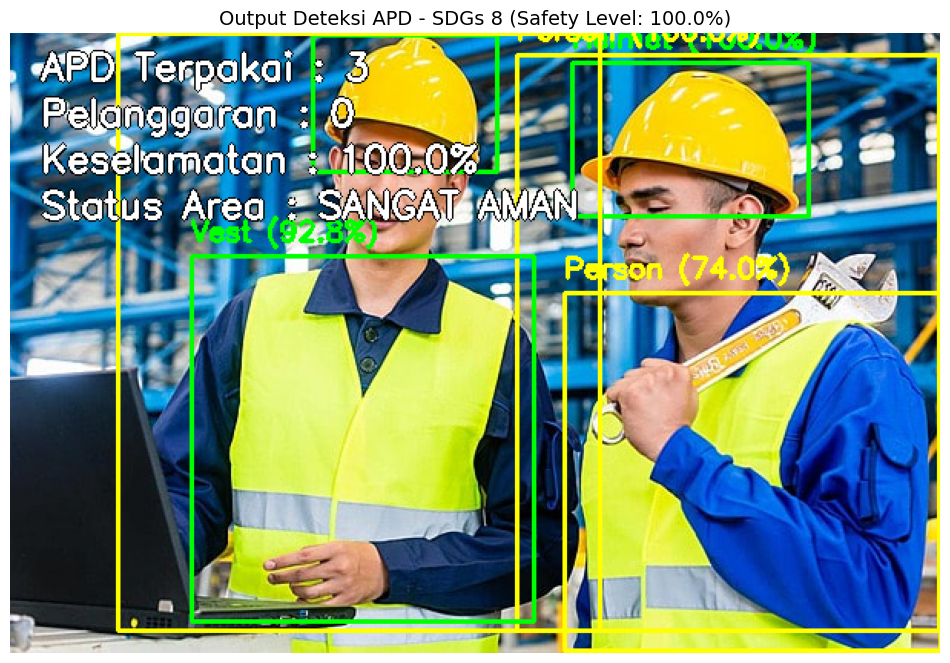


--- LAPORAN KESELAMATAN K3 (SDGs 8.8) ---
Total APD Terpakai     : 3
Total Pelanggaran      : 0
Tingkat Keselamatan    : 100.0%
Status Area            : SANGAT AMAN
-----------------------------------------
Sistem ini membantu industri memantau APD demi keselamatan kerja (SDGs 8.8).


In [ ]:
# CELL 6: OUTPUT - PENGGABUNGAN TWO-STAGE PIPELINE (INFERENCE)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os
import torch
import torch.nn.functional as F

print("\n--- MENJALANKAN PIPELINE TWO-STAGE ---")
# Langsung arahkan ke gambar Anda
test_image_path = '/content/tes.jpg'

if os.path.exists(test_image_path):
    # Load Model
    cnn_model.eval()

    # Baca Gambar
    img = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # STAGE 1: FEATURE EXTRACTION / LOKALISASI OLEH YOLOv8
    print("Stage 1: Ekstraksi fitur dan lokasi oleh YOLOv8...")
    results = yolo_model(test_image_path, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    # STAGE 2: KLASIFIKASI OLEH DEEP LEARNING (CNN)
    print("Stage 2: Klasifikasi objek menggunakan Deep Learning...")
    class_names_idx = image_datasets['train'].classes # Urutan kelas dari ImageFolder

    # Variabel Kalkulasi Tingkat Keselamatan
    safe_items = ['Helmet', 'Gloves', 'Vest', 'Boots', 'Goggles']
    unsafe_items = ['no_helmet', 'no_goggle', 'no_gloves', 'no_boots']
    count_safe = 0
    count_unsafe = 0

    for box in boxes:
        x1, y1, x2, y2 = map(int, box[:4])

        # Potong gambar berdasarkan fitur dari YOLO
        if x2 > x1 and y2 > y1:
            crop_img = img_rgb[y1:y2, x1:x2]
            crop_pil = Image.fromarray(crop_img)

            # Preprocessing Klasifikasi
            input_tensor = data_transforms['val'](crop_pil).unsqueeze(0).to(device)

            # Klasifikasi CNN
            with torch.no_grad():
                output = cnn_model(input_tensor)
                # Menghitung probabilitas (Akurasi Prediksi / Confidence)
                probabilities = F.softmax(output[0], dim=0)
                confidence, pred = torch.max(probabilities, 0)

                predicted_class = class_names_idx[pred.item()]
                conf_score = confidence.item() * 100 # Konversi ke persen

            # Kategorisasi untuk kalkulasi keselamatan & warna bounding box
            if predicted_class in safe_items:
                count_safe += 1
                color = (0, 255, 0) # Hijau (Aman)
            elif predicted_class in unsafe_items:
                count_unsafe += 1
                color = (255, 0, 0) # Merah (Pelanggaran)
            else:
                color = (255, 255, 0) # Kuning (Person/none)

            # Gambar Bounding Box dan Label hasil CNN (beserta akurasi/confidence)
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
            label_text = f"{predicted_class} ({conf_score:.1f}%)"
            cv2.putText(img_rgb, label_text, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Menghitung Tingkat Keselamatan (Safety Score)
    total_items = count_safe + count_unsafe
    safety_score = (count_safe / total_items) * 100 if total_items > 0 else 100.0

    # Menentukan Status Area
    if safety_score >= 80:
        status = "SANGAT AMAN"
    elif safety_score >= 50:
        status = "PERLU PERHATIAN"
    else:
        status = "BAHAYA"

    # Menambahkan Teks Overlay Statistik ke dalam Gambar
    overlay_text = [
        f"APD Terpakai : {count_safe}",
        f"Pelanggaran : {count_unsafe}",
        f"Keselamatan : {safety_score:.1f}%",
        f"Status Area : {status}"
    ]

    y0, dy = 30, 30
    for i, line in enumerate(overlay_text):
        y = y0 + i * dy
        # Memberikan bayangan hitam agar teks terbaca di background terang
        cv2.putText(img_rgb, line, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 4)
        cv2.putText(img_rgb, line, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

    # Tampilkan Output Akhir
    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Output Deteksi APD - SDGs 8 (Safety Level: {safety_score:.1f}%)", fontsize=14)
    plt.show()

    # Cetak Laporan di Console
    print("\n--- LAPORAN KESELAMATAN K3 (SDGs 8.8) ---")
    print(f"Total APD Terpakai     : {count_safe}")
    print(f"Total Pelanggaran      : {count_unsafe}")
    print(f"Tingkat Keselamatan    : {safety_score:.1f}%")
    print(f"Status Area            : {status}")
    print("-----------------------------------------")
    print("Sistem ini membantu industri memantau APD demi keselamatan kerja (SDGs 8.8).")
else:
    print(f"Gambar test tidak ditemukan di {test_image_path}. Harap pastikan gambar sudah diupload.")